In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
print("Loaded Library")

Loaded Library


In [26]:
#load the Data from Dataset Drive
df = pd.read_csv("/content/Capstone1_part2_tesla/Tesla - Deaths.csv")

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307 entries, 0 to 306
Data columns (total 24 columns):
 #   Column                                                                Non-Null Count  Dtype  
---  ------                                                                --------------  -----  
 0   Case #                                                                294 non-null    float64
 1   Year                                                                  294 non-null    float64
 2   Date                                                                  294 non-null    object 
 3    Country                                                              294 non-null    object 
 4    State                                                                294 non-null    object 
 5    Description                                                          295 non-null    object 
 6    Deaths                                                               299 non-null    float64
 7  

In [29]:
df.isnull().sum()

,0
Case #,13
Year,13
Date,13
Country,13
State,13
Description,12
Deaths,8
Tesla driver,13
Tesla occupant,17
Other vehicle,12


Unnamed : 16 & Unnamed : 17 Contain weblink which is not useful
Source: contains web link
Note: contains additonal info
Deceased 1 2 3 and 4 contain name of the deceased which is irrelevent to the analysis
Case # not required
Year can be derived from date


In [30]:
df.shape

(307, 24)

In [31]:
drop_columns=['Case #','Year','Unnamed: 16','Unnamed: 17',' Source ' , ' Note ',' Deceased 1 ',' Deceased 2 ',' Deceased 3 ',' Deceased 4 ']

df.drop(columns=drop_columns, inplace=True)

In [23]:
df.shape

(307, 15)

In [32]:
df.drop(columns = ' Verified Tesla Autopilot Deaths + All Deaths Reported to NHTSA SGO ', inplace = True)

In [33]:
df.columns

Index(['Date', ' Country ', ' State ', ' Description ', ' Deaths ',
       ' Tesla driver ', ' Tesla occupant ', ' Other vehicle ',
       ' Cyclists/ Peds ', ' TSLA+cycl / peds ', ' Model ',
       ' Autopilot claimed ', ' Verified Tesla Autopilot Deaths '],
      dtype='object')

In [35]:
cols = df.columns[5:]
for col in cols:
  if col != ' Model ':
    print(col)
    df[col] = df[col].fillna("-")
    df[col] = df[col].str.strip()
    df[col] = df[col].replace("-", "0")
    df[col] = df[col].astype(int)

 Tesla driver 
 Tesla occupant 
 Other vehicle 
 Cyclists/ Peds 
 TSLA+cycl / peds 
 Autopilot claimed 
 Verified Tesla Autopilot Deaths 


In [36]:
df.head()

,Date,Country,State,Description,Deaths,Tesla driver,Tesla occupant,Other vehicle,Cyclists/ Peds,TSLA+cycl / peds,Model,Autopilot claimed,Verified Tesla Autopilot Deaths
0,1/17/2023,USA,CA,Tesla crashes into back of semi,1.0,1,0,0,0,1,-,0,0
1,1/7/2023,Canada,-,Tesla crashes,1.0,1,0,0,0,1,-,0,0
2,1/7/2023,USA,WA,"Tesla hits pole, catches on fire",1.0,0,1,0,0,1,-,0,0
3,12/22/2022,USA,GA,Tesla crashes and burns,1.0,1,0,0,0,1,-,0,0
4,12/19/2022,Canada,-,Tesla crashes into storefront,1.0,0,0,0,1,1,-,0,0


In [37]:
df.shape

(307, 13)

In [38]:
df.dropna(inplace=True)


In [39]:
df.shape

(294, 13)

Change the Variable names according to python readable

In [40]:
#remove the spaces
df.columns=df.columns.str.strip()


In [42]:
#replace the empty,replace + to _, replace / to _
df.columns=df.columns.str.replace(" ","").str.replace("+","_").str.replace("/","_")
#

In [44]:
df.columns

Index(['Date', 'Country', 'State', 'Description', 'Deaths', 'Tesladriver',
       'Teslaoccupant', 'Othervehicle', 'Cyclists_Peds', 'TSLA_cycl_peds',
       'Model', 'Autopilotclaimed', 'VerifiedTeslaAutopilotDeaths'],
      dtype='object')

In [45]:
#rename the Columns to smaller ones
df.rename(columns = {"Autopilotclaimed":"Claimed", "VerifiedTeslaAutopilotDeaths":"VTAD",
                       "Teslaoccupant" : "Tesla_Occupant", "Othervehicle":'Other_Vehicle',
                       "Tesladriver": "Tesla_Driver"}, inplace = True)

In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 294 entries, 0 to 293
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            294 non-null    object 
 1   Country         294 non-null    object 
 2   State           294 non-null    object 
 3   Description     294 non-null    object 
 4   Deaths          294 non-null    float64
 5   Tesla_Driver    294 non-null    int64  
 6   Tesla_Occupant  294 non-null    int64  
 7   Other_Vehicle   294 non-null    int64  
 8   Cyclists_Peds   294 non-null    int64  
 9   TSLA_cycl_peds  294 non-null    int64  
 10  Model           294 non-null    object 
 11  Claimed         294 non-null    int64  
 12  VTAD            294 non-null    int64  
dtypes: float64(1), int64(7), object(5)
memory usage: 32.2+ KB


In [48]:
df.head()
#So we have Date so derive the per year, per day

,Date,Country,State,Description,Deaths,Tesla_Driver,Tesla_Occupant,Other_Vehicle,Cyclists_Peds,TSLA_cycl_peds,Model,Claimed,VTAD
0,1/17/2023,USA,CA,Tesla crashes into back of semi,1.0,1,0,0,0,1,-,0,0
1,1/7/2023,Canada,-,Tesla crashes,1.0,1,0,0,0,1,-,0,0
2,1/7/2023,USA,WA,"Tesla hits pole, catches on fire",1.0,0,1,0,0,1,-,0,0
3,12/22/2022,USA,GA,Tesla crashes and burns,1.0,1,0,0,0,1,-,0,0
4,12/19/2022,Canada,-,Tesla crashes into storefront,1.0,0,0,0,1,1,-,0,0


In [49]:
#Convert the Data column from Object to Date Column
df['Date'] = pd.to_datetime(df['Date'])

In [50]:
df.info()
#date is converted into datetime64(ns)

<class 'pandas.core.frame.DataFrame'>
Index: 294 entries, 0 to 293
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Date            294 non-null    datetime64[ns]
 1   Country         294 non-null    object        
 2   State           294 non-null    object        
 3   Description     294 non-null    object        
 4   Deaths          294 non-null    float64       
 5   Tesla_Driver    294 non-null    int64         
 6   Tesla_Occupant  294 non-null    int64         
 7   Other_Vehicle   294 non-null    int64         
 8   Cyclists_Peds   294 non-null    int64         
 9   TSLA_cycl_peds  294 non-null    int64         
 10  Model           294 non-null    object        
 11  Claimed         294 non-null    int64         
 12  VTAD            294 non-null    int64         
dtypes: datetime64[ns](1), float64(1), int64(7), object(4)
memory usage: 40.3+ KB


Exploratory Data Analysis

a. Perform an in-depth exploratory data analysis on the number of events by date, per year, and per day for each state and country

b. Analyze the different aspects of the death events. For example:
  
  • What is the number of victims (deaths) in each accident?
  
  • How many times did tesla drivers die?
  
  • What is the proportion of events in which one or more occupants died?
  
  •   What is the distribution of events in which the vehicle hit a cyclist or a pedestrian?
  
  • How many times did the accident involve the death of an occupant or driver of a Tesla along with a cyclist or pedestrian?

  • What is the frequency of Tesla colliding with other vehicles?

a. Perform an in-depth exploratory data analysis on the number of events by date, per year, and per day for each state and country


In [51]:
#add the 3 columns event_year, event_month, event_day
df.loc[:,"event_year"] = df.Date.dt.year
df.loc[:,"event_month"] = df.Date.dt.month
df.loc[:,"event_day"] = df.Date.dt.day

In [52]:
df.columns

Index(['Date', 'Country', 'State', 'Description', 'Deaths', 'Tesla_Driver',
       'Tesla_Occupant', 'Other_Vehicle', 'Cyclists_Peds', 'TSLA_cycl_peds',
       'Model', 'Claimed', 'VTAD', 'event_year', 'event_month', 'event_day'],
      dtype='object')

In [ ]:
#Year wise

#Year wise

In [63]:
df.event_year.value_counts()

,count
event_year,
2022,93
2021,58
2019,46
2020,39
2018,18
2016,15
2017,11
2015,5
2014,4


In [56]:
#Exclude the year 2023 since the value is less
df = df[df.event_year!= 2023]

In [60]:
vc = df.event_year.value_counts()
vc = vc.sort_index()
vc

,count
event_year,
2013,2
2014,4
2015,5
2016,15
2017,11
2018,18
2019,46
2020,39
2021,58


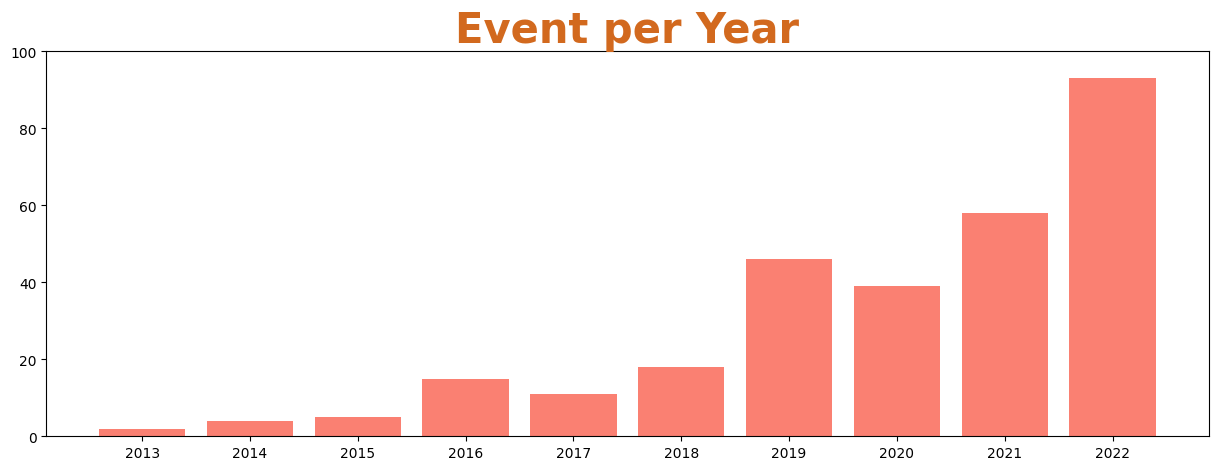

In [64]:
plt.figure(figsize = (15,5))
plt.bar(height = vc.values, x = vc.index, color = "salmon")
plt.xticks(vc.index, vc.index)
#for i in vc.index:
  #plt.annotate(vc[i], xy = (i-0.05, vc[i]+2), size = 13)
plt.ylim(0,100)
plt.title("Event per Year", size = 30, color = "chocolate", weight = "heavy")
plt.show()

#Analysis on the Year wise, the count is increasing

#Month wise

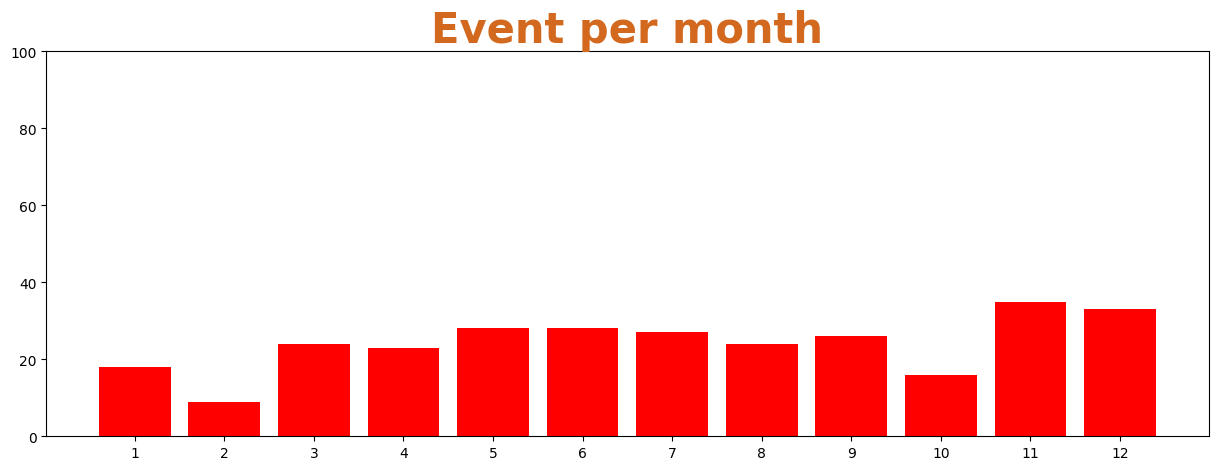

In [72]:
mc = df.event_month.value_counts()
mc = mc.sort_index()

plt.figure(figsize = (15,5))
plt.bar(height = mc.values, x = mc.index, color = "red")
plt.xticks(mc.index, mc.index)
plt.ylim(0,100)
plt.title("Event per month", size = 30, color = "chocolate", weight = "heavy")
plt.show()

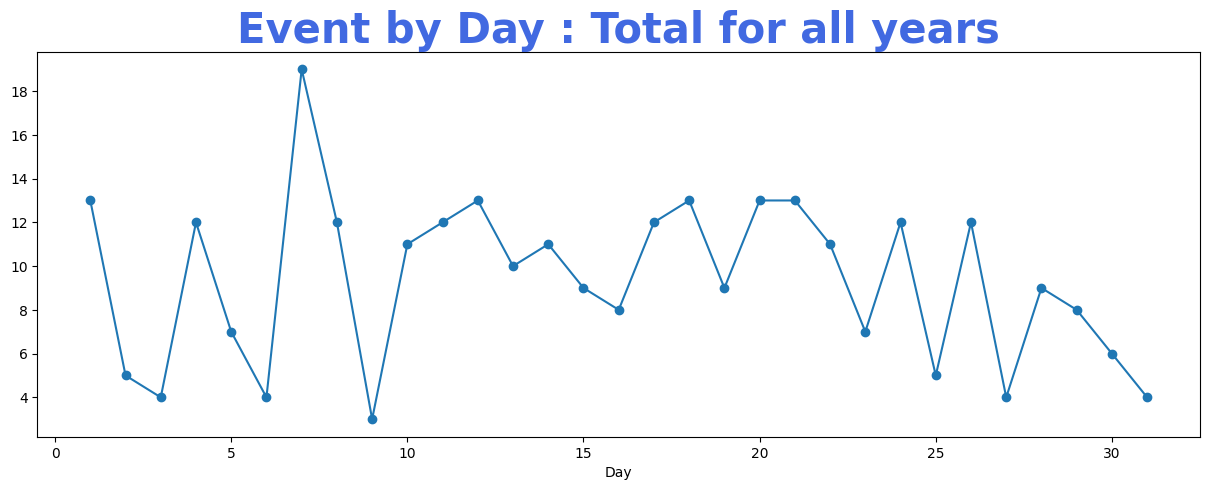

In [69]:
dc = df.event_day.value_counts()
dc = dc.sort_index()
plt.figure(figsize = (15,5))
plt.plot( dc.index, dc.values)
plt.scatter( dc.index, dc.values)
plt.xlabel("Day")
plt.title("Event by Day : Total for all years", size = 30, color = "royalblue",weight = "heavy")
plt.show()

#Country wise and state wise

In [75]:
df["Country"].value_counts()

,count
Country,
USA,213
China,16
Germany,11
Canada,9
Netherlands,6
UK,5
Norway,4
Holland,3
Switzerland,3


/tmp/ipykernel_3942/2173775872.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.annotate(yc[i], xy = (i-0.1, yc[i]+2), size = 10)


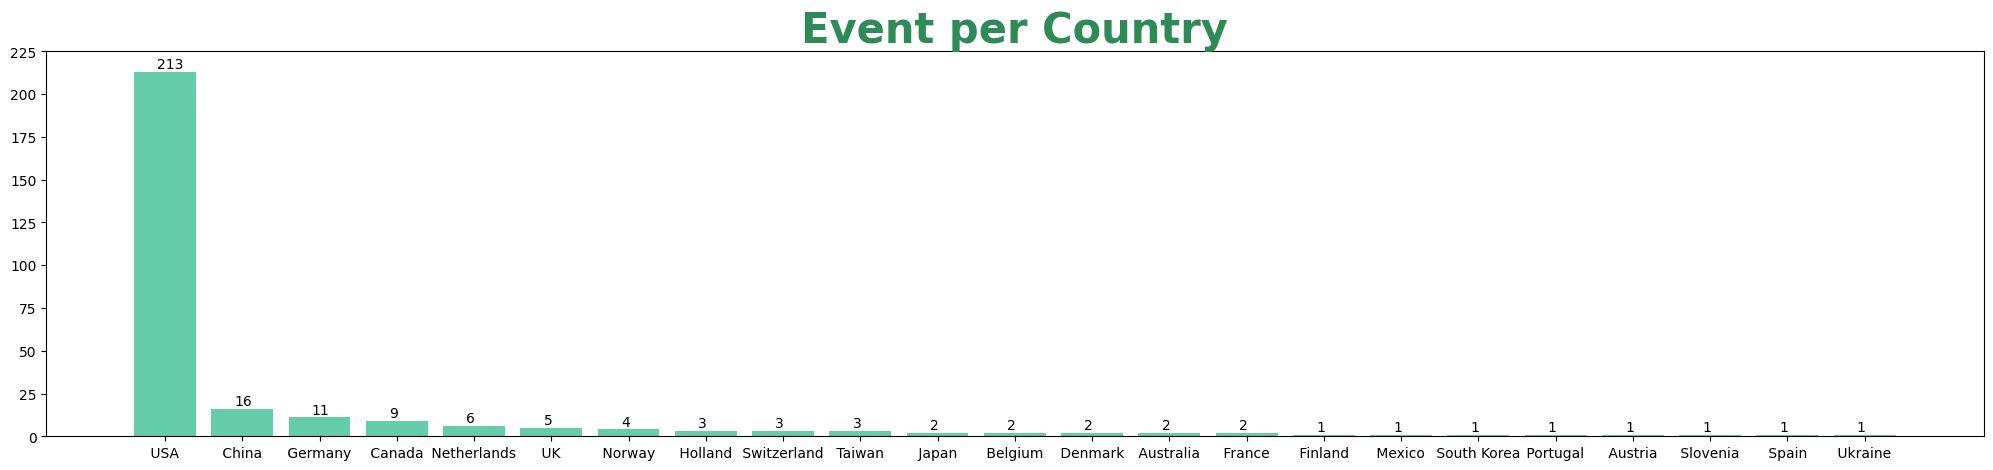

In [80]:
yc = df.Country.value_counts()
yc = mc.sort_index()

yc = df.Country.value_counts()
plt.figure(figsize = (25,5))
plt.bar(height = yc.values, x = yc.index, color = "mediumaquamarine")
plt.xticks(yc.index, yc.index)
for i in range(len(yc.index)):
  plt.annotate(yc[i], xy = (i-0.1, yc[i]+2), size = 10)
plt.title("Event per Country", size = 30, color = "seagreen", weight = "heavy")
plt.ylim(0, 25 * round(yc.max()/25))
plt.show()

state wise

In [82]:
df.State = df.State.str.strip()
df["State"].value_counts()

,count
State,
CA,90
-,78
FL,32
GA,9
AZ,8
PA,7
OH,6
NY,6
UT,5


In [84]:
#remove - states
st = df.State.value_counts()
st = st[st.index != "-"]

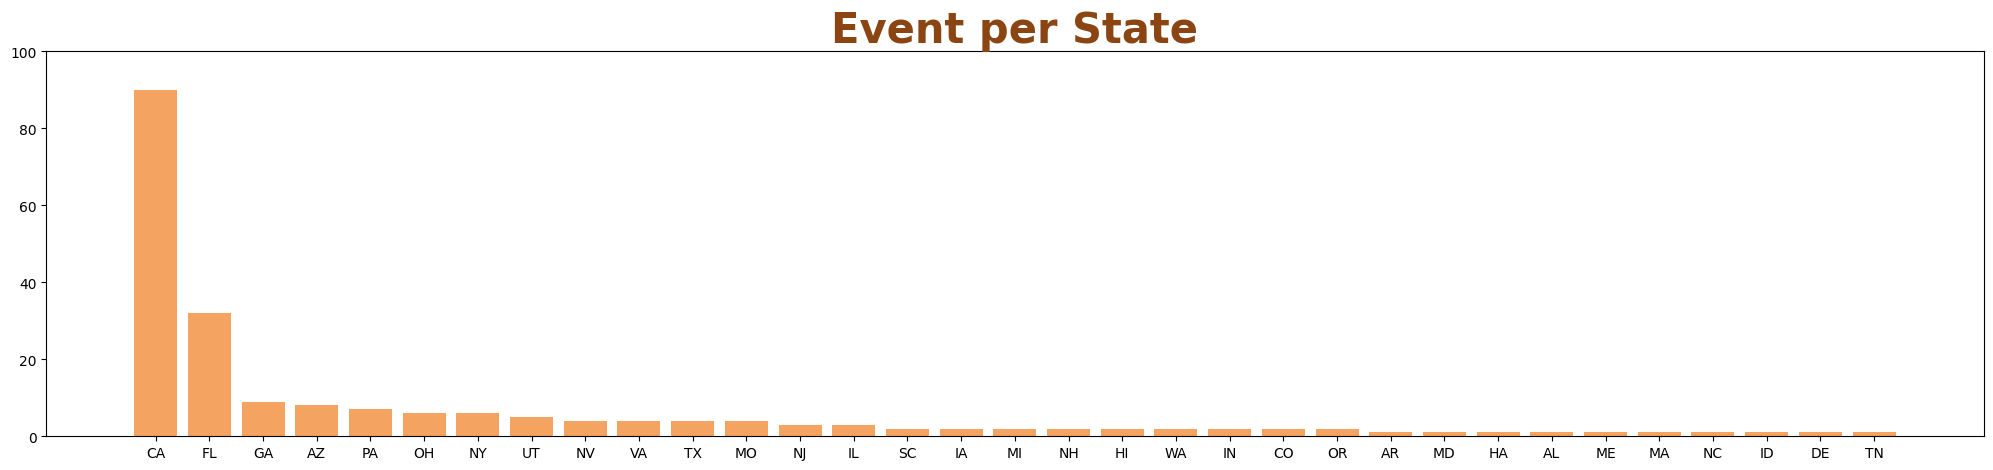

In [85]:
plt.figure(figsize = (25,5))
plt.bar(height = st.values, x = st.index, color = "sandybrown")
plt.xticks(st.index, st.index)
plt.title("Event per State", size = 30, color = "saddlebrown", weight = "heavy")
plt.ylim(0, 25 * round(st.max()/25))
plt.show()

b. Analyze the different aspects of the death events. For example:

  1. What is the number of victims (deaths) in each accident?

  2. How many times did tesla drivers die?

  3. What is the proportion of events in which one or more occupants died?

  4. What is the distribution of events in which the vehicle hit a cyclist or a pedestrian?

  5. How many times did the accident involve the death of an occupant or driver of a Tesla along with a cyclist or pedestrian?

  6. What is the frequency of Tesla colliding with other vehicles

In [89]:
df.head()

,Date,Country,State,Description,Deaths,Tesla_Driver,Tesla_Occupant,Other_Vehicle,Cyclists_Peds,TSLA_cycl_peds,Model,Claimed,VTAD,event_year,event_month,event_day
3,2022-12-22,USA,GA,Tesla crashes and burns,1.0,1,0,0,0,1,-,0,0,2022,12,22
4,2022-12-19,Canada,-,Tesla crashes into storefront,1.0,0,0,0,1,1,-,0,0,2022,12,19
5,2022-12-18,USA,CA,Tesla hit two other cars,1.0,0,1,0,0,0,-,0,0,2022,12,18
6,2022-12-17,USA,CA,Tesla hits pedestrian on highway,1.0,0,0,0,1,1,-,0,0,2022,12,17
7,2022-12-11,USA,CA,Tesla crashes into wall,1.0,1,0,0,0,0,-,0,0,2022,12,11


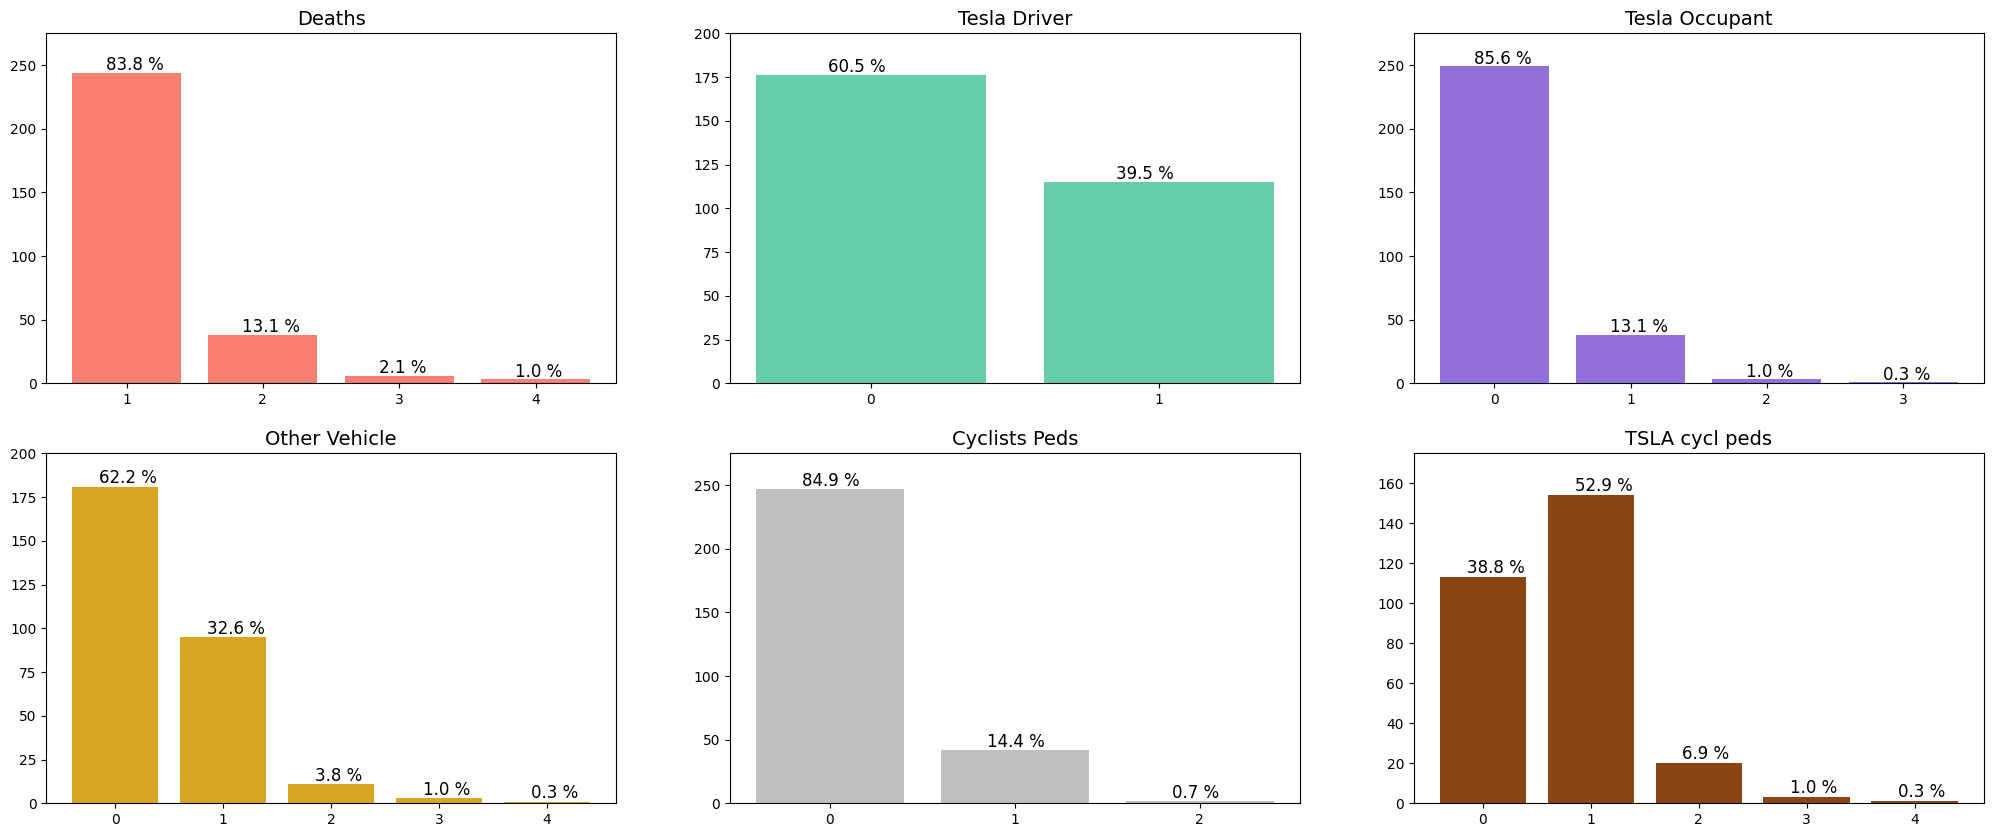

In [98]:
col_list = ['Deaths', 'Tesla_Driver','Tesla_Occupant', 'Other_Vehicle', 'Cyclists_Peds', 'TSLA_cycl_peds']
color = ['salmon', 'mediumaquamarine', 'mediumpurple', 'goldenrod', 'silver', 'saddlebrown']
f,ax = plt.subplots(2,3, figsize = (25,10))
i,j,k = 0,0,0
for col in col_list:
  vc = df[col].value_counts()
  #print(vc)
  vc = vc.sort_index()
  perc = (vc/vc.sum()*100).round(1)
  #print(vc)
  ax[i,j].bar(x = vc.index, height = vc.values, color = color[k])
  ax[i,j].set_title(col.replace("_", " "), size = 14)
  ax[i,j].set_xticks(vc.index)
  for l in vc.index:
    ax[i,j].annotate("{} %".format(perc[l]), xy = (l-0.15,vc[l]+2), size = 12)
    ax[i,j].set_ylim(0,  25 * round(vc.max()/25)+25)
  j += 1
  k += 1
  if j == 3:
    j = 0
    i += 1

#c. Study the event distribution across models

In [100]:
df.Model.value_counts()
#178 times no model are mentioned

,count
Model,
-,178
S,45
3,39
X,17
Y,10
1,1
2,1


/tmp/ipykernel_3942/145752667.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=model_counts.index, y=model_counts.values, palette='plasma')


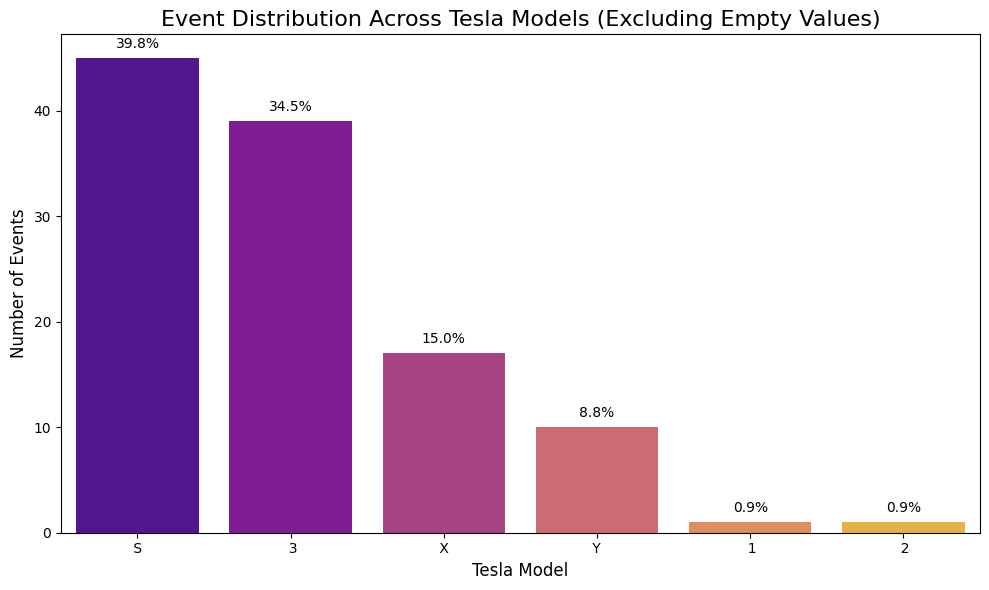

Event distribution across models (excluding empty values):
Model
S      45
 3     39
X      17
Y      10
 1      1
 2      1
Name: count, dtype: int64


In [102]:
model_counts = df[df['Model'] != ' - ']['Model'].value_counts()

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=model_counts.index, y=model_counts.values, palette='plasma')
plt.title('Event Distribution Across Tesla Models (Excluding Empty Values)', fontsize=16)
plt.xlabel('Tesla Model', fontsize=12)
plt.ylabel('Number of Events', fontsize=12)

for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height()/model_counts.sum())
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom', fontsize=10, color='black', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

print("Event distribution across models (excluding empty values):")
print(model_counts)

#d.Check the distribution of verified Tesla autopilot deaths

In [105]:
df.head()

,Date,Country,State,Description,Deaths,Tesla_Driver,Tesla_Occupant,Other_Vehicle,Cyclists_Peds,TSLA_cycl_peds,Model,Claimed,VTAD,event_year,event_month,event_day
3,2022-12-22,USA,GA,Tesla crashes and burns,1.0,1,0,0,0,1,-,0,0,2022,12,22
4,2022-12-19,Canada,-,Tesla crashes into storefront,1.0,0,0,0,1,1,-,0,0,2022,12,19
5,2022-12-18,USA,CA,Tesla hit two other cars,1.0,0,1,0,0,0,-,0,0,2022,12,18
6,2022-12-17,USA,CA,Tesla hits pedestrian on highway,1.0,0,0,0,1,1,-,0,0,2022,12,17
7,2022-12-11,USA,CA,Tesla crashes into wall,1.0,1,0,0,0,0,-,0,0,2022,12,11


In [106]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 291 entries, 3 to 293
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Date            291 non-null    datetime64[ns]
 1   Country         291 non-null    object        
 2   State           291 non-null    object        
 3   Description     291 non-null    object        
 4   Deaths          291 non-null    float64       
 5   Tesla_Driver    291 non-null    int64         
 6   Tesla_Occupant  291 non-null    int64         
 7   Other_Vehicle   291 non-null    int64         
 8   Cyclists_Peds   291 non-null    int64         
 9   TSLA_cycl_peds  291 non-null    int64         
 10  Model           291 non-null    object        
 11  Claimed         291 non-null    int64         
 12  VTAD            291 non-null    int64         
 13  event_year      291 non-null    int32         
 14  event_month     291 non-null    int32         
 15  event_day  

/tmp/ipykernel_3942/3835521166.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=vtad_counts.index.astype(str), y=vtad_counts.values, palette='viridis')


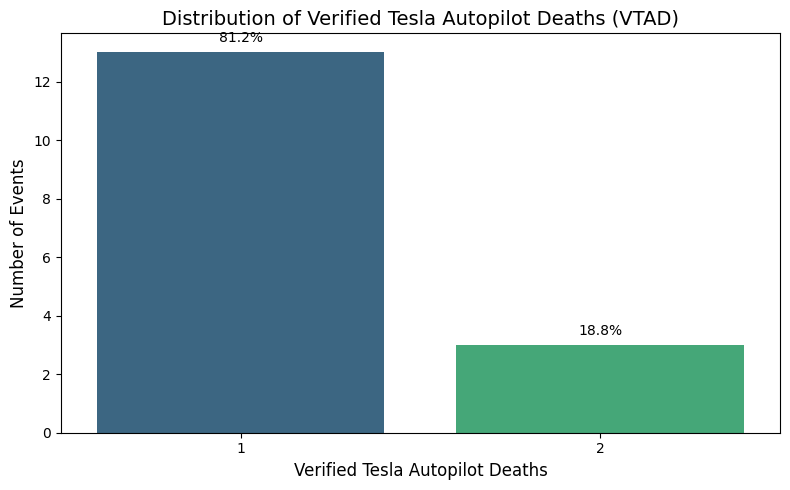

Distribution of Verified Tesla Autopilot Deaths:
VTAD
1    13
2     3
Name: count, dtype: int64


In [108]:
#Exclude the Death Count as 0 since it is not required.
vtad_counts = df[df['VTAD'] != 0]['VTAD'].value_counts().sort_index()

plt.figure(figsize=(8, 5))
ax = sns.barplot(x=vtad_counts.index.astype(str), y=vtad_counts.values, palette='viridis')
plt.title('Distribution of Verified Tesla Autopilot Deaths (VTAD)', fontsize=14)
plt.xlabel('Verified Tesla Autopilot Deaths', fontsize=12)
plt.ylabel('Number of Events', fontsize=12)

for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height()/vtad_counts.sum())
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom', fontsize=10, color='black', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

print("Distribution of Verified Tesla Autopilot Deaths:")
print(vtad_counts)